<a href="https://colab.research.google.com/github/Va1bhav115/klebsiella-amr-prediction/blob/main/copy_of_ai_bioinformatics_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# ============================================================
# CELL 1: Setup + load your labels file
# ============================================================
# Run this cell, then use the upload button that appears to
# select your tb_streptomycin_labels.csv file.

import pandas as pd
import requests
import io
from google.colab import files

print("Upload your labels CSV (tb_streptomycin_labels.csv):")
uploaded = files.upload()
labels_filename = list(uploaded.keys())[0]

labels = pd.read_csv(io.BytesIO(uploaded[labels_filename]))
print("\nColumns found in your file:")
print(list(labels.columns))
print(f"\nTotal rows: {len(labels)}")

Upload your labels CSV (tb_streptomycin_labels.csv):


Saving kleb_meropenem_labels.csv to kleb_meropenem_labels.csv

Columns found in your file:
['Taxon ID', 'Genome ID', 'Genome Name', 'Antibiotic', 'Resistant Phenotype', 'Measurement', 'Measurement Sign', 'Measurement Value', 'Measurement Unit', 'Laboratory Typing Method', 'Laboratory Typing Method Version', 'Laboratory Typing Platform', 'Vendor', 'Testing Standard', 'Testing Standard Year', 'Computational Method', 'Computational Method Version', 'Computational Method Performance', 'Evidence', 'Source', 'PubMed']

Total rows: 7344


In [3]:
# ============================================================
# CELL 2: Clean the labels (safe to re-run)
# ============================================================
# Reload fresh from the uploaded file each time, so re-running
# this cell never hits "column already renamed" errors.
labels = pd.read_csv(io.BytesIO(uploaded[labels_filename]))

# Normalize column names
labels.columns = [c.strip().lower().replace(" ", "_") for c in labels.columns]
print("Normalized columns:", list(labels.columns))

# Keep the two columns we need, with clean names
labels = labels[["genome_id", "resistant_phenotype"]].copy()
labels.columns = ["genome_id", "phenotype"]

# Keep only clean two-class rows
labels = labels[labels["phenotype"].isin(["Resistant", "Susceptible"])]

# Collapse to one row per genome; drop conflicting results
counts = labels.groupby("genome_id")["phenotype"].nunique()
conflicting = counts[counts > 1].index
labels = labels[~labels["genome_id"].isin(conflicting)].drop_duplicates("genome_id")
labels["genome_id"] = labels["genome_id"].astype(str).str.strip()

print(f"\nClean genomes: {len(labels)}")
print(labels["phenotype"].value_counts())
print(f"Dropped {len(conflicting)} genomes with conflicting lab results")

Normalized columns: ['taxon_id', 'genome_id', 'genome_name', 'antibiotic', 'resistant_phenotype', 'measurement', 'measurement_sign', 'measurement_value', 'measurement_unit', 'laboratory_typing_method', 'laboratory_typing_method_version', 'laboratory_typing_platform', 'vendor', 'testing_standard', 'testing_standard_year', 'computational_method', 'computational_method_version', 'computational_method_performance', 'evidence', 'source', 'pubmed']

Clean genomes: 4269
phenotype
Susceptible    2661
Resistant      1608
Name: count, dtype: int64
Dropped 0 genomes with conflicting lab results


In [ ]:
# ============================================================
# CELL 3a: DIAGNOSTIC — confirm connection + discover real fields
# ============================================================
# We pull sp_gene records for ONE known genome with NO extra filters,
# as JSON, so we can see exactly what fields exist and what the
# resistance-category field is really called.

import requests, json

API = "https://www.bv-brc.org/api/sp_gene/"
test_id = labels["genome_id"].iloc[0]   # a real genome from your data
print("Testing with genome_id:", test_id)

r = requests.get(
    API,
    params={"http_accept": "application/json"},
    # GET with the query in the URL via the 'eq' RQL operator:
    # requests will encode this safely
    headers={"Accept": "application/json"},
)
# Build the query URL manually to control encoding
url = f"{API}?eq(genome_id,{test_id})&limit(5)&http_accept=application/json"
r = requests.get(url, timeout=60)
print("HTTP status:", r.status_code)
print("Rows returned:", len(r.json()) if r.text.strip() else 0)

data = r.json() if r.text.strip() else []
if data:
    print("\nField names available in sp_gene:")
    print(list(data[0].keys()))
    print("\nFirst record (sample values):")
    print(json.dumps(data[0], indent=2)[:1500])
else:
    print("\nNo rows — this genome may have no sp_gene entries, "
          "or the query format is off. Tell Claude the status code above.")

Testing with genome_id: 1773.19421
HTTP status: 200
Rows returned: 5

Field names available in sp_gene:
['date_inserted', 'date_modified', 'e_value', 'evidence', 'feature_id', 'function', 'gene', 'genome_id', 'genome_name', 'id', 'identity', 'organism', 'owner', 'patric_id', 'product', 'property', 'property_source', 'public', 'query_coverage', 'same_genus', 'same_species', 'source', 'source_id', 'subject_coverage', 'taxon_id', 'classification', 'pmid', '_version_']

First record (sample values):
{
  "date_inserted": "2020-01-25T14:00:54.197Z",
  "date_modified": "2020-01-25T14:00:54.197Z",
  "e_value": "2e-68",
  "evidence": "BLAT",
  "feature_id": "PATRIC.1773.19421.1773.19421.con.0024.CDS.29384.29773.rev",
  "function": "",
  "gene": "Rv3541c",
  "genome_id": "1773.19421",
  "genome_name": "Mycobacterium tuberculosis ERR176760",
  "id": "cbe2d682-4420-4355-a657-110b3c142434",
  "identity": 100,
  "organism": "Mycobacterium tuberculosis H37Rv",
  "owner": "PATRIC@patricbrc.org",
  "pa

In [ ]:
# ============================================================
# CELL 3b: Find the exact 'property' value for resistance genes
# ============================================================
test_id = labels["genome_id"].iloc[0]
url = f"{API}?eq(genome_id,{test_id})&limit(200)&select(property)&http_accept=application/json"
r = requests.get(url, timeout=60)
props = sorted({rec.get("property", "") for rec in r.json()})
print("Distinct 'property' values seen for this genome:")
for p in props:
    print(f"  {repr(p)}")

Distinct 'property' values seen for this genome:
  'Antibiotic Resistance'
  'Drug Target'
  'Transporter'
  'Virulence Factor'


In [4]:
# ============================================================
# CELL 4: Pull ALL specialty genes for our genomes, filter locally
# ============================================================
import time

API = "https://www.bv-brc.org/api/sp_gene/"
genome_ids = labels["genome_id"].tolist()

def fetch_batch(ids):
    # ONLY the in() filter — this is the combination that works.
    id_list = ",".join(ids)
    url = (
        f"{API}?in(genome_id,({id_list}))"
        f"&select(genome_id,gene,product,property,source,evidence)"
        f"&limit(25000)"
        f"&http_accept=text/csv"
    )
    r = requests.get(url, timeout=180)
    r.raise_for_status()
    if not r.text.strip():
        return pd.DataFrame()
    return pd.read_csv(io.StringIO(r.text))

batches = [genome_ids[i:i+50] for i in range(0, len(genome_ids), 50)]
frames = []
for n, batch in enumerate(batches, 1):
    try:
        df = fetch_batch(batch)
        frames.append(df)
        if n % 20 == 0 or n == len(batches):
            print(f"Batch {n}/{len(batches)} — {len(df)} rows this batch")
    except Exception as e:
        print(f"Batch {n} failed: {e}")
    time.sleep(0.3)

all_genes = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
all_genes["genome_id"] = all_genes["genome_id"].astype(str).str.strip()
print(f"\nAll specialty-gene rows pulled: {len(all_genes)}")
print("Property breakdown:")
print(all_genes["property"].value_counts())

# Filter to resistance genes locally — the reliable way
genes = all_genes[all_genes["property"] == "Antibiotic Resistance"].copy()
print(f"\nAntibiotic Resistance rows: {len(genes)}")
print(f"Genomes with >=1 resistance gene: {genes['genome_id'].nunique()}")
print(f"Unique resistance genes: {genes['gene'].nunique()}")
print("\nSource breakdown:")
print(genes["source"].value_counts())
genes.head()

Batch 20/86 — 25000 rows this batch
Batch 40/86 — 25000 rows this batch
Batch 60/86 — 25000 rows this batch
Batch 80/86 — 25000 rows this batch
Batch 86/86 — 25000 rows this batch

All specialty-gene rows pulled: 2150000
Property breakdown:
property
Transporter              708477
Drug Target              511762
Virulence Factor         396585
Antibiotic Resistance    259626
Metal Resistance         117272
Virulance factor          90242
Human Homolog             66036
Name: count, dtype: int64

Antibiotic Resistance rows: 259626
Genomes with >=1 resistance gene: 1628
Unique resistance genes: 265

Source breakdown:
source
CARD      133453
PATRIC     96307
ARDB       29713
NDARO        153
Name: count, dtype: int64


,genome_id,gene,product,property,source,evidence
7,573.13209,NaN,Multidrug efflux pump EmrD (of MFS type),Antibiotic Resistance,PATRIC,K-mer Search
8,573.13209,NaN,Multidrug resistance protein MdtG,Antibiotic Resistance,ARDB,BLASTP
11,573.13209,NaN,DNA-binding protein H-NS,Antibiotic Resistance,CARD,BLASTP
13,573.13209,NaN,16S rRNA (guanine(527)-N(7))-methyltransferase...,Antibiotic Resistance,PATRIC,K-mer Search
15,573.13209,NaN,Two-component system response regulator OmpR,Antibiotic Resistance,CARD,BLASTP


In [ ]:
# ============================================================
# CELL 4-test: isolate what breaks the multi-genome query
# ============================================================
two = labels["genome_id"].iloc[:2].tolist()
print("Testing with:", two)

# Version A: the 'in' filter ALONE (no property filter), as JSON
urlA = f"{API}?in(genome_id,({','.join(two)}))&limit(5)&http_accept=application/json"
rA = requests.get(urlA, timeout=60)
print("A) in() only        -> status", rA.status_code, "| rows", len(rA.json()) if rA.text.strip() else 0)

# Version B: in() + property, chained with & (no and() wrapper)
urlB = (f"{API}?in(genome_id,({','.join(two)}))"
        f"&eq(property,Antibiotic%20Resistance)&limit(5)&http_accept=application/json")
rB = requests.get(urlB, timeout=60)
print("B) in() & eq()      -> status", rB.status_code, "| rows", len(rB.json()) if rB.text.strip() else 0)

# Version C: the and() wrapper version (what just failed)
urlC = (f"{API}?and(in(genome_id,({','.join(two)})),eq(property,Antibiotic%20Resistance))"
        f"&limit(5)&http_accept=application/json")
rC = requests.get(urlC, timeout=60)
print("C) and(in(),eq())   -> status", rC.status_code, "| rows", len(rC.json()) if rC.text.strip() else 0)

Testing with: ['573.66266', '72407.572']
A) in() only        -> status 200 | rows 5
B) in() & eq()      -> status 200 | rows 0
C) and(in(),eq())   -> status 200 | rows 0


In [5]:
# ============================================================
# CELL 5: Build feature matrix (use product when gene is missing)
# ============================================================
import numpy as np

g = genes.copy()
# Klebsiella often leaves 'gene' blank but fills 'product'.
# Use gene when present, otherwise fall back to product.
g["feature"] = g["gene"].fillna("").replace("", np.nan)
g["feature"] = g["feature"].fillna(g["product"])
g = g.dropna(subset=["feature"])           # drop rows with neither
g["feature"] = g["feature"].astype(str).str.strip()

pairs = g[["genome_id", "feature"]].drop_duplicates()
pairs["present"] = 1

feature_matrix = pairs.pivot_table(
    index="genome_id", columns="feature", values="present", fill_value=0
)
print("Feature matrix shape (genomes x features):", feature_matrix.shape)

data = labels.set_index("genome_id").join(feature_matrix, how="left")
gene_cols = feature_matrix.columns.tolist()
data[gene_cols] = data[gene_cols].fillna(0).astype(int)

print("Final dataset shape:", data.shape)
print("\nLabel balance after join:")
print(data["phenotype"].value_counts())
print(f"\nGenomes with zero resistance features: {(data[gene_cols].sum(axis=1) == 0).sum()}")
data.head()

Feature matrix shape (genomes x features): (1628, 490)
Final dataset shape: (4269, 491)

Label balance after join:
phenotype
Susceptible    2661
Resistant      1608
Name: count, dtype: int64

Genomes with zero resistance features: 2641


,phenotype,1-deoxy-D-xylulose 5-phosphate reductoisomerase (EC 1.1.1.267),16S rRNA (guanine(527)-N(7))-methyltransferase (EC 2.1.1.170),23S rRNA (adenine(2058)-N(6))-dimethyltransferase (EC 2.1.1.184) => Erm(B),"3-oxoacyl-[acyl-carrier-protein] synthase, KASII (EC 2.3.1.179)",4-deoxy-4-formamido-L-arabinose-phosphoundecaprenol deformylase ArnD (EC 3.5.1.n3),"AAC(3)-II,III,IV,VI,VIII,IX,X",AAC(3)-IIa,AAC(3)-IIc,AAC(6')-Ib,...,vgaC,ybhT,ybjG,yibH_3,yibH_5,yojI,yokD,yusO,yusO_1,yycF
genome_id,,,,,,,,,,,,,,,,,,,,,
573.66266,Resistant,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
72407.572,Resistant,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
573.13209,Susceptible,1,1,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1284814.3,Susceptible,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
573.14343,Susceptible,0,1,0,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# ============================================================
# CELL 5b: sanity check — do resistant genomes carry more resistance genes?
# ============================================================
data["n_resistance_genes"] = data[gene_cols].sum(axis=1)
print("Mean # resistance genes per genome, by phenotype:")
print(data.groupby("phenotype")["n_resistance_genes"].mean())
print("\n% of genomes with zero resistance genes, by phenotype:")
zero_by_class = data.groupby("phenotype").apply(
    lambda g: (g["n_resistance_genes"] == 0).mean() * 100
)
print(zero_by_class)

Mean # resistance genes per genome, by phenotype:
phenotype
Resistant      30.084577
Susceptible    42.974821
Name: n_resistance_genes, dtype: float64

% of genomes with zero resistance genes, by phenotype:
phenotype
Resistant      70.460199
Susceptible    56.670425
dtype: float64


/tmp/ipykernel_13756/1937481656.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data["n_resistance_genes"] = data[gene_cols].sum(axis=1)
/tmp/ipykernel_13756/1937481656.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  zero_by_class = data.groupby("phenotype").apply(


In [6]:
# CELL 5c: look for the actual carbapenemase genes
mask = genes["product"].fillna("").str.contains(
    "carbapenem|KPC|NDM|OXA-48|OXA-23|VIM|IMP|metallo-beta-lactamase|class A beta",
    case=False, regex=True)
carb = genes[mask]
print("Carbapenemase-like gene rows found:", len(carb))
print("Genomes carrying one:", carb["genome_id"].nunique())
print("\nTop matching products:")
print(carb["product"].value_counts().head(15))

carrier_ids = set(carb["genome_id"])
data["has_carbapenemase"] = data.index.isin(carrier_ids).astype(int)
print("\nCarbapenemase presence vs phenotype:")
print(pd.crosstab(data["phenotype"], data["has_carbapenemase"], normalize="index").round(3))

Carbapenemase-like gene rows found: 11777
Genomes carrying one: 1593

Top matching products:
product
Class A beta-lactamase (EC 3.5.2.6) => SHV family                                             5254
Class A beta-lactamase (EC 3.5.2.6) => CTX-M family, extended-spectrum                        3059
Class A beta-lactamase (EC 3.5.2.6) => TEM family                                             1867
Class A beta-lactamase (EC 3.5.2.6) => KPC family, carbapenem-hydrolyzing                     1260
Class A beta-lactamase (EC 3.5.2.6) => VEB family, extended-spectrum                            77
Subclass B1 beta-lactamase (EC 3.5.2.6) => NDM family                                           61
Class A beta-lactamase (EC 3.5.2.6) => LAP family                                               57
Class A beta-lactamase (EC 3.5.2.6) => LEN family                                               48
Class D beta-lactamase (EC 3.5.2.6) => OXA-48 family, some variants carbapenem-hydrolyzing      25
Class A 

/tmp/ipykernel_8607/1508581007.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data["has_carbapenemase"] = data.index.isin(carrier_ids).astype(int)


In [7]:
# ============================================================
# CELL 5d: TRUE carbapenemases only (KPC, NDM, OXA-48, VIM, IMP)
# ============================================================
# Only families that actually hydrolyze carbapenems — not all beta-lactamases.
true_carb = genes["product"].fillna("").str.contains(
    "KPC family|NDM family|OXA-48|VIM family|IMP family|carbapenem-hydrolyzing",
    case=False, regex=True)
carb = genes[true_carb]
print("True carbapenemase rows:", len(carb))
print("Genomes carrying a true carbapenemase:", carb["genome_id"].nunique())
print("\nFamilies found:")
print(carb["product"].value_counts())

carrier_ids = set(carb["genome_id"])
data["has_true_carb"] = data.index.isin(carrier_ids).astype(int)
print("\nTrue carbapenemase vs phenotype (row-normalized):")
print(pd.crosstab(data["phenotype"], data["has_true_carb"], normalize="index").round(3))
print("\nCounts:")
print(pd.crosstab(data["phenotype"], data["has_true_carb"]))

True carbapenemase rows: 1347
Genomes carrying a true carbapenemase: 452

Families found:
product
Class A beta-lactamase (EC 3.5.2.6) => KPC family, carbapenem-hydrolyzing                     1260
Subclass B1 beta-lactamase (EC 3.5.2.6) => NDM family                                           61
Class D beta-lactamase (EC 3.5.2.6) => OXA-48 family, some variants carbapenem-hydrolyzing      25
Class D beta-lactamase (EC 3.5.2.6) => OXA-24 family, carbapenem-hydrolyzing                     1
Name: count, dtype: int64

True carbapenemase vs phenotype (row-normalized):
has_true_carb      0      1
phenotype                  
Resistant      0.743  0.257
Susceptible    0.986  0.014

Counts:
has_true_carb     0    1
phenotype               
Resistant      1194  414
Susceptible    2623   38


/tmp/ipykernel_8607/3917816873.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data["has_true_carb"] = data.index.isin(carrier_ids).astype(int)


In [8]:
# ============================================================
# CELL 6: Train a random forest classifier
# ============================================================
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve)

# Features = all gene/product columns; target = phenotype
X = data[gene_cols].values
y = (data["phenotype"] == "Resistant").astype(int).values  # 1 = Resistant

# Stratified split keeps class balance in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print(f"Train: {X_train.shape[0]} genomes | Test: {X_test.shape[0]} genomes")
print(f"Features: {X_train.shape[1]}")

# class_weight balances the 60/40 split so it doesn't just predict majority
clf = RandomForestClassifier(
    n_estimators=300, max_depth=None, class_weight="balanced",
    random_state=42, n_jobs=-1
)
clf.fit(X_train, y_train)

# Evaluate
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

print("\n=== Classification report (test set) ===")
print(classification_report(y_test, y_pred, target_names=["Susceptible", "Resistant"]))
print("Confusion matrix [rows=true, cols=pred]:")
print(confusion_matrix(y_test, y_pred))
print(f"\nROC-AUC: {roc_auc_score(y_test, y_proba):.3f}")

Train: 3201 genomes | Test: 1068 genomes
Features: 490

=== Classification report (test set) ===
              precision    recall  f1-score   support

 Susceptible       0.88      0.40      0.55       666
   Resistant       0.48      0.91      0.63       402

    accuracy                           0.59      1068
   macro avg       0.68      0.66      0.59      1068
weighted avg       0.73      0.59      0.58      1068

Confusion matrix [rows=true, cols=pred]:
[[265 401]
 [ 35 367]]

ROC-AUC: 0.713


In [10]:
# ============================================================
# CELL 6b: compare default vs balanced weighting
# ============================================================
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

for label, weight in [("default (no balancing)", None),
                      ("balanced", "balanced")]:
    clf = RandomForestClassifier(
        n_estimators=300, class_weight=weight,
        random_state=42, n_jobs=-1
    )
    clf.fit(X_train, y_train)
    pred = clf.predict(X_test)
    proba = clf.predict_proba(X_test)[:, 1]
    print(f"\n===== {label} =====")
    print(classification_report(y_test, pred, target_names=["Susceptible","Resistant"]))
    print("Confusion:\n", confusion_matrix(y_test, pred))
    print(f"ROC-AUC: {roc_auc_score(y_test, proba):.3f}")


===== default (no balancing) =====
              precision    recall  f1-score   support

 Susceptible       0.68      0.98      0.80       666
   Resistant       0.89      0.22      0.35       402

    accuracy                           0.70      1068
   macro avg       0.78      0.60      0.58      1068
weighted avg       0.76      0.70      0.63      1068

Confusion:
 [[655  11]
 [313  89]]
ROC-AUC: 0.744

===== balanced =====
              precision    recall  f1-score   support

 Susceptible       0.88      0.40      0.55       666
   Resistant       0.48      0.91      0.63       402

    accuracy                           0.59      1068
   macro avg       0.68      0.66      0.59      1068
weighted avg       0.73      0.59      0.58      1068

Confusion:
 [[265 401]
 [ 35 367]]
ROC-AUC: 0.713


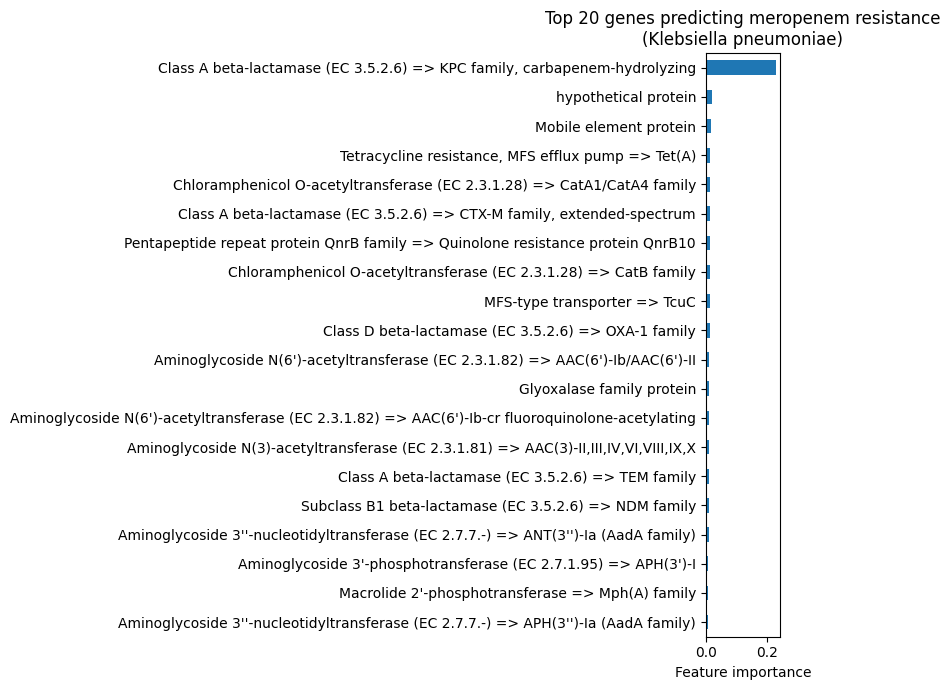

Top 15 predictive genes:
  0.2306  Class A beta-lactamase (EC 3.5.2.6) => KPC family, carbapenem-hydrolyz
  0.0199  hypothetical protein
  0.0171  Mobile element protein
  0.0154  Tetracycline resistance, MFS efflux pump => Tet(A)
  0.0137  Chloramphenicol O-acetyltransferase (EC 2.3.1.28) => CatA1/CatA4 famil
  0.0133  Class A beta-lactamase (EC 3.5.2.6) => CTX-M family, extended-spectrum
  0.0132  Pentapeptide repeat protein QnrB family => Quinolone resistance protei
  0.0129  Chloramphenicol O-acetyltransferase (EC 2.3.1.28) => CatB family
  0.0128  MFS-type transporter => TcuC
  0.0124  Class D beta-lactamase (EC 3.5.2.6) => OXA-1 family
  0.0121  Aminoglycoside N(6')-acetyltransferase (EC 2.3.1.82) => AAC(6')-Ib/AAC
  0.0120  Glyoxalase family protein
  0.0110  Aminoglycoside N(6')-acetyltransferase (EC 2.3.1.82) => AAC(6')-Ib-cr 
  0.0103  Aminoglycoside N(3)-acetyltransferase (EC 2.3.1.81) => AAC(3)-II,III,I
  0.0101  Class A beta-lactamase (EC 3.5.2.6) => TEM family


In [9]:
# ============================================================
# CELL 7: Which genes drive the predictions? (the headline figure)
# ============================================================
import matplotlib.pyplot as plt

# Refit the default model (higher AUC) on the training data
clf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)

importances = pd.Series(clf.feature_importances_, index=gene_cols)
top = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(8, 7))
top[::-1].plot(kind="barh")
plt.xlabel("Feature importance")
plt.title("Top 20 genes predicting meropenem resistance\n(Klebsiella pneumoniae)")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("Top 15 predictive genes:")
for name, val in top.head(15).items():
    print(f"  {val:.4f}  {name[:70]}")

In [11]:
# ============================================================
# CELL 8: Cross-validated comparison of classifiers
# ============================================================
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
import numpy as np

# 5-fold stratified CV keeps the class ratio in every fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Random Forest":        RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    "Gradient Boosting":    GradientBoostingClassifier(n_estimators=200, random_state=42),
}

print(f"{'Model':<22}{'ROC-AUC (mean ± std)':<24}{'Accuracy (mean ± std)'}")
print("-" * 70)
for name, model in models.items():
    auc = cross_val_score(model, X, y, cv=cv, scoring="roc_auc", n_jobs=-1)
    acc = cross_val_score(model, X, y, cv=cv, scoring="accuracy", n_jobs=-1)
    print(f"{name:<22}{auc.mean():.3f} ± {auc.std():.3f}        {acc.mean():.3f} ± {acc.std():.3f}")

Model                 ROC-AUC (mean ± std)    Accuracy (mean ± std)
----------------------------------------------------------------------
Logistic Regression   0.751 ± 0.014        0.615 ± 0.013
Random Forest         0.753 ± 0.010        0.700 ± 0.007
Gradient Boosting     0.759 ± 0.011        0.710 ± 0.006


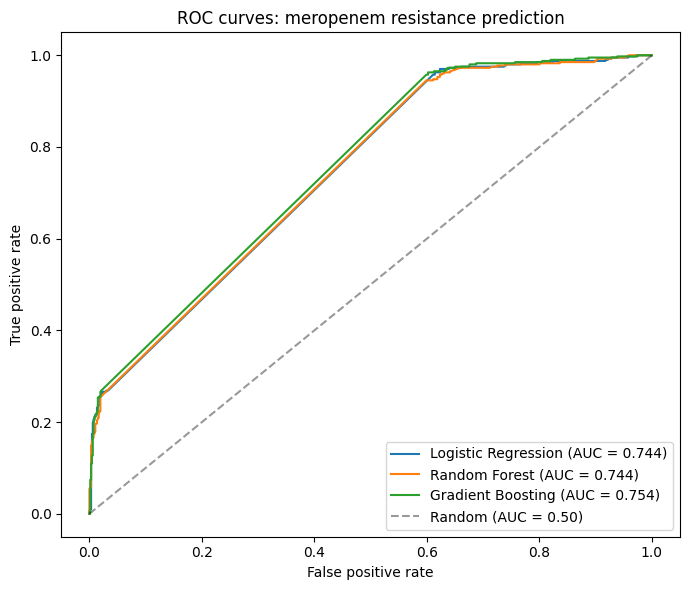

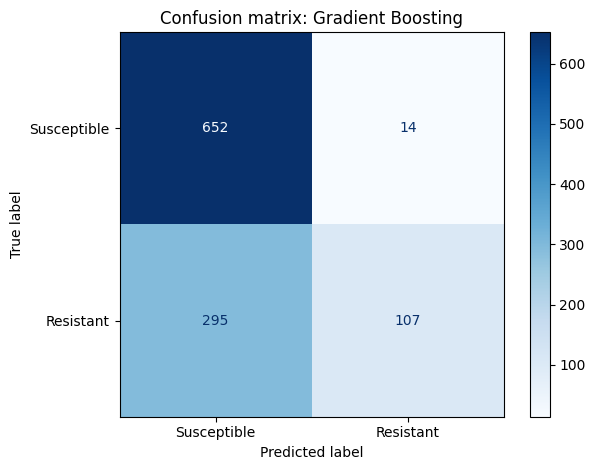

In [12]:
# ============================================================
# CELL 9: ROC curves + confusion matrix figures
# ============================================================
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

# ---- ROC curves for all three models ----
plt.figure(figsize=(7, 6))
for name, model in models.items():
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc(fpr, tpr):.3f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Random (AUC = 0.50)")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curves: meropenem resistance prediction")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()

# ---- Confusion matrix for the best model (gradient boosting) ----
best = GradientBoostingClassifier(n_estimators=200, random_state=42)
best.fit(X_train, y_train)
cm = confusion_matrix(y_test, best.predict(X_test))
disp = ConfusionMatrixDisplay(cm, display_labels=["Susceptible", "Resistant"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion matrix: Gradient Boosting")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()